# Satellite Land Cover trend assessment for Spatial Planning and Land Management

Production date: 05-06-2026

Produced by: Inês Girão (+ATLANTIC)

## 🌍 Use case: Using land cover products to quantify wetland trends

## ❓ Quality assessment question
* **Is the dataset suitable for the analysis of wetland trends in Ireland?**

Land Cover data is an invaluable resource for a wide range of fields, from climate change research to landscape management. Land Cover products that provide historical timelines enable scientists, policymakers, and planners to understand and analyse the transformation of land cover over recent decades ([EUROSTAT,2022](https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Forests,_forestry_and_logging); [New EU Forest Strategy for 2030](https://commission.europa.eu/document/cf3294e1-8358-4c93-8de4-3e1503b95201_en)).

This notebook will access the ***Land cover classification gridded maps from 1992 to present derived from satellite observations*** (henceforth, LC) data from the Climate Data Store (CDS) of the Copernicus Climate Change Service (C3S), and analyse the spatial patterns of a specific LC type over a given Area of Interest (AoI) and time.



## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note

The dataset shows good temporal continuity for broad-scale wetland land-cover monitoring in Ireland. Although a breakpoint was identified, it does not substantially disrupt the overall time series or require a segmented trend. This supports the use of the dataset for long-term national wetland trend assessment.

The detected breakpoint should be interpreted as a sensitivity indicator rather than definitive evidence of abrupt wetland change. It highlights a period where the mapped wetland signal departs from the longer-term pattern, but its limited effect on the preferred trend suggests that the overall temporal structure remains stable.

For the wetland class analysed, the similarity between the total and segmented trend outputs indicates that the dataset captures the underlying long-term pattern without strong distortion from short-term variability. This suggests that the full-period trend provides a robust summary of mapped wetland dynamics, while breakpoint outputs remain useful for flagging periods that may require closer contextual validation.


```

![wetland_ireland](wetland_ireland.png)

## 📋 Methodology

**This Use Case comprises the following steps:**

**[](code-section-1)**

**[](code-section-2)**

**[](code-section-3)**

**[](code-section-4)**

**[](code-section-5)**

## 📈 Analysis and results

(code-section-1)=
### **1. Define the AoI, search and download LC data**
Before we begin we must prepare our environment. This includes installing the Application Programming Interface (API) of the CDS, and importing the various python libraries that we will need.

#### Install CDS API
To install the CDS API, run the following command. We use an exclamation mark to pass the command to the shell (not to the Python interpreter).
If you already have the CDS API installed, you can skip or comment this step.

In [1]:
!pip install cdsapi

Defaulting to user installation because normal site-packages is not writeable


##### Import all the libraries/packages

We will be working with data in NetCDF format. To best handle this type of data we will use libraries for working with multidimensional arrays, in particular Xarray. 
We will also need libraries for plotting and viewing data.

In [ ]:
#  Import Standard Libraries
import random
from collections import defaultdict

#  Import Numerical & Statistical Libraries
import numpy as np
import pandas as pd
import xarray as xr
import dask
from scipy.stats import linregress, f, kendalltau, theilslopes
from statsmodels.api import OLS
from numpy.polynomial.polynomial import Polynomial
import pymannkendall as mk

# import ruptures as rpt
import ruptures as rpt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from scipy.signal import savgol_filter

#  Import Geospatial Libraries
import geopandas as gpd  # Import vector geospatial data
import regionmask  # Transform attributes and geometries into specific regions
from shapely.geometry import box, Polygon


#  Import Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.patches import Patch
from IPython.display import display
from matplotlib.lines import Line2D
from collections import defaultdict
from IPython.display import display, HTML
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

#  Import External Tools
from c3s_eqc_automatic_quality_control import download, plot, utils


#  Set Matplotlib Style
plt.style.use("seaborn-v0_8-notebook")  # Predefined style for all graphical outputs

# Set the CDSAPI location
import os
os.environ["CDSAPI_RC"] = "/data/wp5/girao_ines/.cdsapirc"

##### Data Overview

To search for data, visit the CDS website: http://cds.climate.copernicus.eu Here you can search for 'Satellite observations' using the search bar. The data we need for this tutorial is the ***Land cover classification gridded maps from 1992 to present derived from satellite observations***. This catalogue entry provides global Land Cover Classification (LCC) maps with a very high spatial resolution, with a L4 processing level, on an annual basis with a one-year delay, following the [Global Climate Observing System (GCOS) convention requirements](https://library.wmo.int/records/item/58111-the-2022-gcos-ecvs-requirements-gcos-245). LULC maps correspond to a global classification scheme, encompassing 22 classes.

The dataset consists of 2 versions (v2.0.7 produced by the European Space Agency (ESA) Climate Change Initiative (CCI) and v2.1.1 produced by Copernicus Climate Change Service (C3S)).

Data specifications for this use case:
* **Years:** 1992 to 2022
* **Version:** v2.0.7 before 1992 and v2.1.1 after 2016
* **Format:** Zip files

At the end of the download form, select “**Show API request**”. This will reveal a block of code, which you can simply copy and paste into a cell of your Jupyter Notebook. Having copied the API request, running it will retrieve and download the data you requested into your local directory. However, before you run it, the **terms and conditions** of this particular dataset need to have been accepted directly at the CDS website. The option to view and accept these conditions is given at the end of the download form, just above the “**Show API request**” option. In addition, it is also useful to define the time period and AoI parameters and edit the request accordingly, as exemplified in the cells below.

In [3]:
#Years to download
years = [1992, 1993, 1994,
        1995, 1996, 1997,
        1998, 1999, 2000,
        2001, 2002, 2003,
        2004, 2005, 2006,
        2007, 2008, 2009,
        2010, 2011, 2012,
        2013, 2014, 2015,
        2016, 2017, 2018,
        2019, 2020, 2021,
        2022, 2022]


# List of requests to retrieve data
collection_id = "satellite-land-cover"
requests = [
    {
        "variable": "all",
        "format": "zip",
        "version": "v2_0_7cds" if year < 2016 else "v2_1_1",
        "year": str(year),
        "area": [56, -11, 51, -5]  # Ireland region of interest: [North, West, South, East]
    }
    for year in years
]

In [ ]:
# Download and regionalize by AoI
ds = download.download_and_transform(
    collection_id,
    requests,
)
ds = ds.assign_coords(year=ds["time"].dt.year).swap_dims(time="year").drop("time")
 

In [5]:
#Inspect the database
ds

<xarray.Dataset> Size: 1GB
Dimensions:              (year: 31, latitude: 1800, longitude: 2160, bounds: 2)
Coordinates:
  * year                 (year) int64 248B 1992 1993 1994 ... 2020 2021 2022
  * latitude             (latitude) float64 14kB 56.0 56.0 55.99 ... 51.0 51.0
  * longitude            (longitude) float64 17kB -11.0 -11.0 ... -5.004 -5.001
    lat_bounds           (latitude, bounds) float64 29kB dask.array<chunksize=(1800, 2), meta=np.ndarray>
    lon_bounds           (longitude, bounds) float64 35kB dask.array<chunksize=(2160, 2), meta=np.ndarray>
    time_bounds          (year, bounds) datetime64[ns] 496B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: bounds
Data variables:
    lccs_class           (year, latitude, longitude) uint8 121MB dask.array<chunksize=(1, 1800, 2160), meta=np.ndarray>
    processed_flag       (year, latitude, longitude) float32 482MB dask.array<chunksize=(1, 1800, 2160), meta=np.ndarray>
    current_pixel_state  (year, latitude, longitude) float32 482MB dask.array<chunksize=(1, 1800, 2160), meta=np.ndarray>
    observation_count    (year, latitude, longitude) uint16 241MB dask.array<chunksize=(1, 1800, 2160), meta=np.ndarray>
    change_count         (year, latitude, longitude) uint8 121MB dask.array<chunksize=(1, 1800, 2160), meta=np.ndarray>
    crs                  (year) int32 124B -2147483647 ... -2147483647
Attributes: (12/38)
    id:                         ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds
    title:                      Land Cover Map of ESA CCI brokered by CDS
    summary:                    This dataset characterizes the land cover of ...
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y
    project:                    Climate Change Initiative - European Space Ag...
    references:                 http://www.esa-landcover-cci.org/
    ...                         ...
    geospatial_lon_max:         180
    spatial_resolution:         300m
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.002778
    geospatial_lon_units:       degrees_east
    geospatial_lon_resolution:  0.002778

(code-section-2)=
### **2. Inspect and view data for the defined AoI (Ireland)**
#### Compute wetland area for each NUTS 0 region

To identify changes in LC patterns, in this user question, NUTS 0 will be used, providing the information regarding Ireland.

The [NUTS](https://ec.europa.eu/eurostat/web/nuts) are a hierarchical system divided into 3 levels. NUTS 0 correspond to the contry, NUTS 1 correspond to major socio-economic regions, NUTS 2 correspond to basic regions for the application of regional policies, and NUTS 3 correspond to small regions for specific diagnoses. Additionally a NUTS 0 level, usually co-incident with national boundaries is also available. The NUTS legislation is periodically amended; therefore multiple years are available for download. 


The step below masks the Land Cover data according to the NUTS 0 boundaries and calculate the area of each pixel (weighted by the cosine of Latitude). For each NUTS 2, we proceed with the analysis and visual inspection of Land Cover areas per class and corresponding percentages during the elected period.

#### Mask regions

First, we need to establish the geometry of the NUTS region (level 0) in order to make the corresponding statistics.

In [6]:
# Configure Dask
dask.config.set(scheduler='threads', **{'array.slicing.split_large_chunks': True})

# Define CRS and bounding box for Ireland
crs_wgs84 = "EPSG:4326"

# Load and filter GeoDataFrame
shapefile_url = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/shp/NUTS_RG_20M_2021_4326.shp.zip"
gdf = gpd.read_file(shapefile_url)
gdf = gdf[gdf["LEVL_CODE"] == 0]
gdf = gdf[gdf["NUTS_ID"].str.startswith(("IE"))]  # Ireland (IE)
gdf = gdf.to_crs(crs_wgs84)
gdf = gdf[gdf.geometry.is_valid & ~gdf.geometry.is_empty]

if gdf.empty:
    raise ValueError("No valid geometries found after filtering.")

# Ensure dataset CRS is set
if ds.rio.crs is None:
    ds = ds.rio.write_crs("EPSG:4326", inplace=True)

# Ensure dataset coordinates overlap with the filtered regions
filtered_lon_min, filtered_lat_min, filtered_lon_max, filtered_lat_max = gdf.total_bounds
if (
    ds["longitude"].min().values > filtered_lon_max
    or ds["longitude"].max().values < filtered_lon_min
    or ds["latitude"].min().values > filtered_lat_max
    or ds["latitude"].max().values < filtered_lat_min
):
    raise ValueError(
        "Dataset coordinates do not overlap with the filtered regions. Check dataset and region alignment."
    )

# Subset dataset to valid ranges
ds = ds.sel(
    longitude=slice(
        max(filtered_lon_min, ds["longitude"].min().values),
        min(filtered_lon_max, ds["longitude"].max().values)
    ),
    latitude=slice(
        min(filtered_lat_max, ds["latitude"].max().values),
        max(filtered_lat_min, ds["latitude"].min().values)
    )
)

# Check subsetted dataset dimensions
if ds["longitude"].size == 0 or ds["latitude"].size == 0:
    raise ValueError("Subsetting resulted in an empty dataset. Check the bounds and ensure overlap.")

# Create the regionmask
regions = regionmask.from_geopandas(gdf, names="NUTS_NAME")

# Create a 2D mask
mask = regions.mask(ds["longitude"], ds["latitude"])

ds= ds.where(mask.notnull(), drop=True)

#### Compute cell area

Then, we can calculate the area of each pixel taking into consideration the curvature of the earth (i.e., weighted by the cosine of Latitude).

In [7]:
# Scaling factor for conversion (constant longitude resolution)
scaling_factor = 0.002778  # Degrees
resolution_lon_km = scaling_factor * 111.195  # Longitude resolution in kilometers

# Use the latitude values directly from the dataset
lats = ds["latitude"]

# Calculate the difference between consecutive latitude values
lat_diff = np.abs(np.diff(lats.values))  # Absolute differences
lat_diff = np.append(lat_diff, lat_diff[-1])  # Assume the last cell has the same size as the one before

# Convert latitude differences to kilometers
resolution_lat_km = lat_diff * 111.195  # Latitude-dependent resolution

# Compute the grid cell area for each latitude
grid_cell_area = resolution_lon_km * resolution_lat_km * np.cos(np.radians(lats))

# Assign attributes to the grid cell area
grid_cell_area.attrs = {
    "standard_name": "cell_area",
    "long_name": "Grid cell area",
    "units": "km²",
}

# Add the grid cell area as a coordinate to the dataset
ds = ds.assign_coords(cell_area=("latitude", grid_cell_area.data))  # Use `.data` to extract the array

#### Select Wetland Classes and Prepare Dataset

In [8]:
# Define wetland classes
wetland_classes = [160,170,180] #Tree cover, flooded, fresh or brackish water Tree cover, flooded, saline water Shrub or herbaceous cover, flooded, fresh/saline/brackish water 

# Create a mask for wetland areas
wetland_mask = ds['lccs_class'].isin(wetland_classes)

# Masked wetland area using cell area
ds_wetland_area = ds['cell_area'].where(wetland_mask)

# Stack latitude and longitude into a single dimension
ds_wetland_area = ds_wetland_area.stack(stacked_lat_lon=("latitude", "longitude"))

# Create a stacked mask and align dimensions
stacked_mask = mask.stack(stacked_lat_lon=("latitude", "longitude"))
stacked_mask.name = "stacked_mask"

# Attach the stacked mask to the dataset
ds_wetland_area = ds_wetland_area.assign_coords(stacked_mask=stacked_mask)

# Group by regions and compute wetland area for each year
wetland_area_by_region = (
    ds_wetland_area.groupby("stacked_mask")
    .sum(dim="stacked_lat_lon")
    .compute()
)

#### Compute wetland area per region and year

In [9]:
results = []
growth = {}

for reg, reg_area in wetland_area_by_region.groupby("stacked_mask"):
    if np.isnan(reg):  # Skip NaN regions
        continue

    # Ensure valid region indexing and naming
    region_name = regions[int(reg)].name
    years = ds_wetland_area['year'].values
    values = reg_area.values.flatten()  # Flatten in case of higher-dimensional arrays

    # Save growth data by year
    if len(values) > 0:
        growth[region_name] = {int(year): float(value) for year, value in zip(years, values)}
    else:
        growth[region_name] = {}  # Handle regions with no data

    # Add results to the list
    for year, value in zip(years, values):
        results.append({
            "Region": region_name,
            "Year": int(year),
            "wetland_Area": float(value)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Add geometry to results_df
if 'NUTS_NAME' in gdf.columns:
    results_df = pd.merge(results_df, gdf[['NUTS_NAME', 'geometry']], left_on="Region", right_on="NUTS_NAME", how="left")
else:
    print("Warning: NUTS_NAME column not found in gdf.")

# Ensure results_df is a GeoDataFrame
if not isinstance(results_df, gpd.GeoDataFrame):
    results_df = gpd.GeoDataFrame(results_df, geometry=gpd.GeoSeries(results_df['geometry']), crs="EPSG:4326")

Available years: [1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


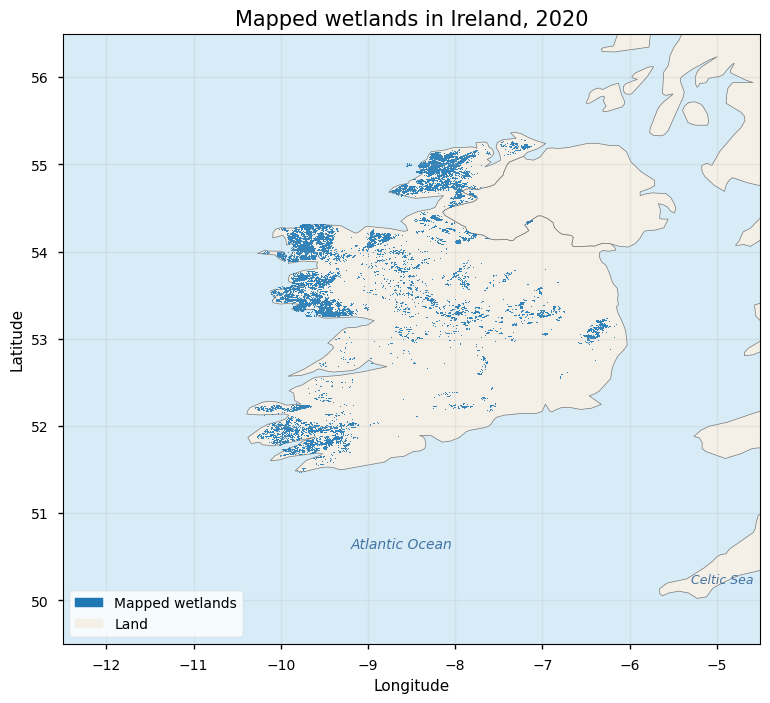

In [ ]:
# Wetland map with geographic context around Ireland

selected_year = 2020  # change this year

natural_earth_url = (
    "https://naturalearth.s3.amazonaws.com/"
    "50m_cultural/ne_50m_admin_0_countries.zip"
)

world = gpd.read_file(natural_earth_url)

context_countries = world[
    world["NAME"].isin([
        "Ireland",
        "United Kingdom",
        "France",
        "Isle of Man"
    ])
].to_crs("EPSG:4326")


if "year" in ds.dims and hasattr(ds.indexes.get("year", None), "duplicated"):
    ds_map = ds.sel(year=~ds.indexes["year"].duplicated())
else:
    ds_map = ds

available_years = [int(y) for y in ds_map["year"].values]
print("Available years:", available_years)

if selected_year not in available_years:
    raise ValueError(
        f"Year {selected_year} is not available. "
        f"Choose one of: {available_years}"
    )

lc_year = ds_map["lccs_class"].sel(year=selected_year)

if "year" in lc_year.dims:
    lc_year = lc_year.isel(year=0)

wetland_pixels = lc_year.isin(wetland_classes)
wetland_pixels = wetland_pixels.where(wetland_pixels)


fig, ax = plt.subplots(figsize=(9, 10))

# Sea background
ax.set_facecolor("#d7ecf7")

# Land masses only, with soft boundaries
context_countries.plot(
    ax=ax,
    color="#f4f0e8",
    edgecolor="#777777",
    linewidth=0.5
)

# Wetlands
wetland_pixels.plot(
    ax=ax,
    x="longitude",
    y="latitude",
    cmap=ListedColormap(["#1f78b4"]),
    add_colorbar=False,
    alpha=0.9
)

# Wider map extent
ax.set_xlim(-12.5, -4.5)
ax.set_ylim(49.5, 56.5)

# Sea labels only
ax.text(
    -9.2, 50.6,
    "Atlantic Ocean",
    fontsize=10,
    style="italic",
    color="#336699",
    alpha=0.9
)

ax.text(
    -5.3, 50.2,
    "Celtic Sea",
    fontsize=9,
    style="italic",
    color="#336699",
    alpha=0.9
)

# Legend
wetland_patch = mpatches.Patch(color="#1f78b4", label="Mapped wetlands")
land_patch = mpatches.Patch(color="#f4f0e8", label="Land")

ax.legend(
    handles=[wetland_patch, land_patch],
    loc="lower left",
    frameon=True
)

ax.set_title(f"Mapped wetlands in Ireland, {selected_year}", fontsize=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)

plt.show()

#### **Potential Drivers and Methodological Considerations in Wetland Trends in the Ireland (1992–2022)**

The size of wetlands areas, in the Ireland, over the last three decades has been influenced by a combination of **economic shifts**, **demographic changes**, and **policy decisions**. Before analysing trends, it is essential to account for abrupt shifts that may distort trend estimates. These shifts, often referred to as breakpoints, can result from:

**Economic Drivers**

- **Peat extraction and turf cutting**  
  Historic and recent peat extraction, including domestic turf cutting, industrial peat harvesting, horticultural peat extraction, and energy-related peat use, has been a major driver of wetland and peatland degradation in Ireland. Drainage and burning are recognised as destructive forces associated with peat extraction, while turbary and mechanical cutting have contributed substantially to peatland habitat loss ([Irish Peatland Conservation Council, 2020](https://www.ipcc.ie/a-to-z-peatlands/irelands-peatland-conservation-action-plan/peatland-action-plan/habitat-loss-of-peatlands/)). Drainage for industrial and domestic peat extraction has also been identified as a cause of long-term peatland water-quality degradation ([EPA, 2024a](https://www.epa.ie/publications/compliance--enforcement/drinking-water/annual-drinking-water-reports/FINAL-EPA_DrinkingWaterQualityinPublicSupplies2024-v1.4.pdf)).  
  Relevant breakpoint periods may include the decline of industrial peat extraction and the expansion of peatland rehabilitation and restoration programmes in the late 2010s and early 2020s, particularly following the establishment of the Bord na Móna Bog Rehabilitation Scheme and the Peatlands Climate Action Scheme ([Government of Ireland, 2020](https://www.gov.ie/en/department-of-climate-energy-and-the-environment/publications/bord-na-m%C3%B3na-bog-rehabilitation-scheme/); [Bord na Móna, n.d.](https://www.bnm.ie/peatlands/peatland-restoration/)). Recent studies also show that rewetting degraded Irish raised bogs can rapidly alter carbon dynamics, confirming that restoration interventions may generate detectable ecological and biogeochemical shifts in the post-extraction landscape ([Aitova et al., 2025](https://doi.org/10.3390/land14112226); [Renou-Wilson et al., 2019](https://doi.org/10.1016/j.ecoleng.2018.02.014)).


- **Agricultural drainage and land reclamation**  
  Drainage of wet soils for pasture improvement, grazing, silage production, and field consolidation has historically reduced wetland extent and altered peatland condition. National research on Irish grassland peat soils shows that large areas of peatland have been transformed from their natural state to grassland agriculture, although the extent and effectiveness of drainage varies spatially ([Tuohy et al., 2023](https://doi.org/10.1016/j.jenvman.2023.118391); [Teagasc, 2023](https://teagasc.ie/wp-content/uploads/2025/05/Study-shows-area-of-drained-grassland-peat-soils-is-grossly-overestimated.pdf)). National-scale mapping of peatland drainage status further highlights the importance of drainage as a key variable for interpreting peatland land-use condition in Ireland ([Bari et al., 2025](https://doi.org/10.30955/gnc2025.00123); [Habib et al., 2024](https://doi.org/10.1002/rse2.387)). In land-cover time series, this may appear as conversion from wetland or semi-natural vegetation classes to grassland or cropland-related classes. Hydrological studies of cultivated peat soils also show that drainage design, peat thickness, and groundwater interactions can strongly influence water-table behaviour and soil condition ([Tähtikarhu et al., 2025](https://doi.org/10.1080/09064710.2025.2454388)).


- **Forestry on peat soils**  
  Afforestation on peatlands can alter hydrology through drainage, canopy interception, evapotranspiration, and soil disturbance. Forestry is identified as one of the major land uses affecting Irish peatlands, and restoration projects on afforested peatlands have used tree removal and drain blocking to rewet previously drained bog areas ([Coillte](https://www.coillte.ie/our-business/our-projects/nature-conservation/); [European Commission LIFE Programme](https://webgate.ec.europa.eu/life/publicWebsite/project/LIFE02-NAT-IRL-008490/restoring-active-blanket-bog-in-ireland)). Research on afforested peatlands in the maritime temperate zone shows that forestry on peat soils has important implications for soil carbon balance and greenhouse gas exchange ([Jovani-Sancho et al., 2021](https://doi.org/10.1111/gcb.15654)). More broadly, recent European peatland research argues that active afforestation of drained peatlands is not a viable restoration option under the EU Nature Restoration Law, because it does not restore peatland hydrological or ecological function ([Jurasinski et al., 2024](https://doi.org/10.1007/s13280-024-02016-5)).  
  In the C3S Land Cover product, such changes may appear as transitions from open wetland, shrubland, grassland, or sparse vegetation classes toward tree-cover classes. Conversely, forest removal or restoration on peat soils may create apparent transitions back toward open vegetation, wetland, or water classes.
  

- **Post-industrial peatland after-use and restoration**  
  Cutaway bogs may follow different post-extraction trajectories, including rewetting, open-water formation, wet grassland development, scrub colonisation, forestry, renewable-energy development, or managed restoration. Bord na Móna rehabilitation plans describe expected outcomes such as rewetting, environmental stabilisation, development of naturally functioning peatland and wetland habitats, wet deep peat vegetation, wetland habitats on shallow peat, open water, reed swamp, and fen habitats ([EPA, 2025](https://leap.epa.ie/docs/0bb0df04-15a7-471e-9d16-d258233d5c06.pdf); [Bord na Móna](https://www.bnm.ie/peatlands/peatland-restoration/)). Evidence from a cutover raised bog in Ireland shows that vegetation recovery can occur following rewetting measures, although recovery trajectories vary by site condition and management history ([Crowley et al., 2022](https://doi.org/10.3318/bioe.2021.09)). Systematic review evidence also shows that peat extraction after-use can have diverse biodiversity, climate, hydrological, and social impacts depending on the selected after-use pathway ([Räsänen et al., 2023](https://doi.org/10.1016/j.scitotenv.2023.163583)). These changes may produce spatially heterogeneous signals in the land-cover time series.


**Hydrological, Climatic, and Environmental Drivers**

- **Drainage, rewetting, and water-table change**  
  Wetland trends are highly sensitive to hydrological conditions. Rewetting, drain blocking, and restoration interventions are widely used in Irish peatland restoration to raise water levels and promote the redevelopment of peat-forming or wetland habitats ([Bord na Móna](https://www.bnm.ie/peatlands/peatland-restoration/); [NPWS, 2017](https://www.npws.ie/maps-and-data/designated-site-data/ssco-data)). Irish studies of rewetted raised bogs demonstrate that rewetting can support climate and biodiversity benefits and change carbon dynamics, but outcomes depend on local hydrological recovery and vegetation response ([Renou-Wilson et al., 2019](https://doi.org/10.1016/j.ecoleng.2018.02.014); [Aitova et al., 2025](https://doi.org/10.3390/land14112226); [Shamsuzzaman et al., 2025](https://doi.org/10.3897/aca.8.e148818)). Conversely, active drainage or prolonged drying can reduce wetland detectability and shift vegetation toward drier communities.


- **Rainfall variability, drought, and extreme weather**  
  Interannual climate variability can affect the spectral appearance of wetlands, particularly shallow flooded habitats, cutaway bogs, wet grasslands, turloughs, and coastal wetlands. Irish turloughs are strongly controlled by hydrological regimes, and remote sensing has been used to reconstruct flood-level time series in seasonal wetlands ([McCormack et al., 2023](https://doi.org/10.1016/j.rse.2023.113839)). Drought can also affect Irish peatlands by increasing wildfire risk and ecological degradation, as documented for the 2018 drought ([EPA, 2023](https://www.epa.ie/publications/research/water/EPA-Report-SinglePage-446.pdf)). These effects should not automatically be interpreted as permanent land-cover change. More generally, peatland restoration pathways are strongly mediated by hydrology, climate, and carbon feedbacks ([Mander et al., 2023](https://doi.org/10.1007/s10533-023-01103-1); [Temmink et al., 2023](https://doi.org/10.1007/s13280-023-01875-8)).


- **Coastal and estuarine dynamics**  
  Ireland’s coastal wetlands, saltmarshes, lagoons, mudflats, and estuarine margins may respond to sea-level rise, storm surges, sediment dynamics, erosion, accretion, and coastal flood-defence works. The Geological Survey Ireland National Coastal Change Assessment identifies relative sea-level rise, shoreline erosion and accretion, tidal range, wave height, coastal slope, and geomorphology as key indicators of sea-level-related coastal change in Ireland ([Geological Survey Ireland](https://www.gsi.ie/en-ie/programmes-and-projects/marine-and-coastal-unit/projects/Pages/National-Coastal-Change-Assessment.aspx)). Historic land reclamation has also substantially altered intertidal wetlands in the Shannon Estuary, illustrating the importance of long-term human modification in Irish coastal wetland interpretation ([Healy & Hickey, 2002](https://doi.org/10.2112/1551-5036-36.sp1.365)). Saltmarsh research further highlights the importance of accretion, sea-level rise, and storm effects for long-term marsh resilience ([EPA, 2020](https://www.epa.ie/publications/research/water/Research_Report_313.pdf); [Möller et al., 2021](https://doi.org/10.1016/j.geomorph.2021.107847)). Because many coastal wetlands are narrow or fragmented, they may be difficult to resolve reliably at 300 m spatial resolution.


- **Fire, grazing, and vegetation disturbance**  
  Burning, overgrazing, undergrazing, scrub expansion, and vegetation recovery can alter the spectral characteristics of peatland and wetland habitats. Burning can damage peatland vegetation, including Sphagnum mosses, and may be particularly damaging where peat has dried due to prior disturbance ([Irish Peatland Conservation Council](https://www.ipcc.ie/advice/peatland-management-diy-tool-kit/restoration-of-burned-peatlands/); [IUCN UK Peatland Programme, 2024](https://www.iucn-uk-peatlandprogramme.org/sites/default/files/2024-06/State%20of%20UK%20Peatlands.pdf)). Heavy grazing and trampling can reduce vegetation cover, damage peat-forming plants, and contribute to erosion on bogs ([Natura Communities](https://www.naturacommunities.ie/protecting-and-restoring/threats/); [Teagasc, 2022](https://teagasc.ie/wp-content/uploads/media/website/publications/2022/Ecological-Value-and-Condition-of-Irelands-Uplands_CD-210722.pdf)). These processes may produce transitions among shrubland, grassland, sparse vegetation, and wetland classes without necessarily indicating full hydrological restoration or complete wetland loss.


**Policy and Conservation Influences**

- **EU conservation designations and Natura 2000**  
  Special Areas of Conservation, Special Protection Areas, Natural Heritage Areas, and Natura 2000 protections have influenced the management of raised bogs, blanket bogs, fens, turloughs, saltmarshes, and other wetland habitats. EU LIFE and Natura 2000 projects in Ireland have supported restoration of active blanket bog and raised bog habitats, including work on afforested peatlands and sites within the Natura 2000 network ([European Commission LIFE Programme](https://webgate.ec.europa.eu/life/publicWebsite/project/LIFE02-NAT-IRL-008490/restoring-active-blanket-bog-in-ireland); [Raised Bog Restoration Ireland, n.d.](https://raisedbogs.ie/)). Peatland restoration is also increasingly framed as part of wider EU sustainability and nature-based-solutions policy, with relevance for climate, biodiversity, water regulation, and rural land-use objectives ([Tanneberger et al., 2020](https://doi.org/10.1002/adsu.202000146); [Farrell et al., 2024](https://doi.org/10.1111/rec.14216)). These protections may reduce direct conversion pressures and support restoration, although ecological and hydrological recovery may lag policy implementation.


- **National Peatlands Strategy**  
  Ireland’s National Peatlands Strategy provides an important policy framework for peatland conservation, restoration, climate mitigation, water regulation, agriculture, forestry, energy, and community use. It recognises peatlands as providing services including biodiversity maintenance, carbon storage and sequestration, water regulation, flood attenuation, agriculture, forestry, fuel, employment, wind energy, amenity, and peat for horticulture ([Department of Arts, Heritage and the Gaeltacht, 2015](https://www.npws.ie/sites/default/files/general/Final%20National%20Peatlands%20Strategy.pdf)). The mid-2010s may therefore be a relevant period to examine for policy-related changes in wetland or peatland trends. The Strategy was later updated through a Mid-Term Review and Implementation Plan, which prioritised measurable and achievable actions ([Government of Ireland, 2023](https://www.gov.ie/en/department-of-housing-local-government-and-heritage/publications/national-peatlands-strategy-mid-term-review-and-implementation-plan/)). Recent restoration-framework research in Ireland also emphasises the need for coordinated restoration planning, prioritisation, monitoring, and governance structures ([Farrell et al., 2024](https://doi.org/10.1111/rec.14216)).


- **Climate Action and land-use policy**  
  Peatland restoration has become increasingly linked to climate mitigation, biodiversity protection, flood regulation, and just transition policy. Ireland’s Bord na Móna Bog Rehabilitation Scheme was established to deliver climate action benefits, including reduced emissions, carbon storage, biodiversity enhancement, employment, and contribution to carbon-neutrality objectives ([Government of Ireland, 2020](https://www.gov.ie/en/department-of-climate-energy-and-the-environment/publications/bord-na-m%C3%B3na-bog-rehabilitation-scheme/)). National-scale peatland land-use mapping in Ireland has quantified major peatland land-use changes and associated implications for CO₂ emissions, reinforcing the relevance of land-cover monitoring for climate policy ([Habib & Connolly, 2023](https://doi.org/10.1007/s10113-023-02116-0); [Habib et al., 2024](https://doi.org/10.1038/s41598-024-51660-0)). Restoration and rehabilitation initiatives may generate local increases in wetland, open-water, or flooded vegetation classes, particularly in former industrial peat extraction areas.
  

- **Bord na Móna peatland rehabilitation and restoration**  
  Rehabilitation of former industrial peatlands, including drain blocking and rewetting, may produce detectable changes in surface wetness and vegetation. The Peatlands Climate Action Scheme aims to optimise the climate benefits of rewetting former industrial peat production areas by creating wet peatland conditions that allow compatible peatland habitats to redevelop. Bord na Móna also describes drain blocking and rewetting as methods for returning bogs toward peat-forming conditions ([Bord na Móna](https://www.bnm.ie/peatlands/peatland-restoration/)). Empirical studies of Irish raised bog restoration show vegetation recovery, altered carbon fluxes, and hydrological recovery following rewetting, supporting the interpretation of post-restoration land-cover transitions as potentially real ecological change where corroborated by site evidence ([Crowley et al., 2022](https://doi.org/10.3318/bioe.2021.09); [Renou-Wilson et al., 2019](https://doi.org/10.1016/j.ecoleng.2018.02.014); [Shamsuzzaman et al., 2025](https://doi.org/10.3897/aca.8.e148818)). However, these effects are likely to be spatially variable and may not always be captured as class 180 wetland in a 300 m land-cover product.


**Methodology**

- Certain shifts in wetland land cover may be related to data collection and processing rather than actual wetland expansion. For instance, transitions between different satellite sensors can introduce artificial breaks in the time series [(Chelali et al., 2019)](https://doi.org/10.1109/JURSE.2019.8808967).

- **The LC dataset is generated from a multi-sensor surface reflectance time series derived from several satellite missions. As sensor technology evolved, different instruments were used to produce consistent global composites.**

<div style="display: flex; justify-content: center;">

| Surface Reflectance (SR) Input | Reference Period | Satellite Sensor / Mission | Main Characteristics |
|---|---|---|---|
| AVHRR SR composites | 1992–1999 | AVHRR-2 (NOAA-11, NOAA-14) | ~1 km spatial resolution, visible and near-infrared observations |
| SPOT-VGT SR composites | 1999–2013 | SPOT-4 / SPOT-5 VEGETATION | 1 km spatial resolution, 4 spectral bands (blue, red, NIR, SWIR) |
| MERIS SR composites | 2003–2012 | Envisat MERIS | ~300 m spatial resolution, 15 spectral bands in visible and near-infrared |
| PROBA-V SR composites | 2013–2019 | PROBA-V | ~300 m spatial resolution, 4 spectral bands (blue, red, NIR, SWIR) |
| Sentinel-3 SR composites | 2020 | Sentinel-3 OLCI | ~300 m spatial resolution, multispectral observations |
| Sentinel-3 SR composites | 2021–2022 | Sentinel-3 OLCI + SLSTR | Optical and thermal observations supporting land-cover mapping |
</div>
<div style="text-align: center;">
Source: See Figure 1-3 in <a href="https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=documentation">C3S, LC - Product User Guide and Specification (2024)</a>
</div>

- In addition to optical surface reflectance observations, auxiliary datasets are used to improve land-cover mapping. In particular, **Envisat ASAR Wide Swath Mode (WSM)** radar observations (2005–2012) are incorporated as ancillary information [(C3S - LC Target Requirements and Gap Analysis Document, 2024)](https://dast.copernicus-climate.eu/documents/satellite-land-cover/WP3-TR-GAD-2023_LC_v1.1_final.pdf).

- While the dataset relies on multiple satellite sensors, it is not generated through simple sensor-to-sensor transitions. Instead, the global land-cover time series is built around a baseline land-cover map derived from MERIS observations (2003–2012). Earlier periods (1992–2003) are reconstructed through back-dating using AVHRR and SPOT-VGT data, while later years are produced through incremental updates using SPOT-VGT, PROBA-V, and Sentinel-3 observations. During several periods, multiple sensors are used simultaneously, with different roles (e.g., temporal consistency versus spatial refinement). As a result, potential discontinuities in the time series are more likely to arise from changes in processing strategy, data fusion, and constraints, rather than from simple sensor replacements.

<div style="display: flex; justify-content: center;">

| Global LC database | Reference period | Satellite data source |
|---|---|---|
| Baseline 10-year global LC map | 2003–2012 | • MERIS FR/RR global SR composites between 2003 and 2012 |
| Global annual LC maps | 1992–1999 | • Baseline 10-year global LC map <br> • AVHRR global SR composites between 1992 and 1999 for back-dating the baseline |
|  | 1999–2013 | • Baseline 10-year global LC map <br> • SPOT-VGT global SR composites between 1999 and 2013 for up- and back-dating the baseline <br> • MERIS FR global SR composites between 2003 and 2012 to delineate the identified changes at 300 m spatial resolution <br> • PROBA-V global SR composites at 300 m for year 2013 to delineate the identified changes at 300 m spatial resolution |
|  | 2014–2019 | • PROBA-V global SR composites at 1 km for years 2014 to 2019 for updating the baseline <br> • PROBA-V time series at 300 m for 2014 to 2019 to delineate the identified changes at the LC map spatial resolution |
|  | 2020–2022 | • S3 global SR composites at 1 km for years 2020 to 2022 for updating the baseline <br> • S3 time series at 300 m for 2020 to 2022 to delineate the identified changes at the LC map spatial resolution |
</div>
<div style="text-align: center;">
Source: See Table 1-3 in <a href="https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=documentation">C3S, LC - Product User Guide and Specification (2024)</a>
</div>

(code-section-3)=
### **3. Breakpoint Detection**

A first step in assessing temporal behaviour is to analyse the **rate of change** of the wetland-area time series. This provides an intuitive view of how the pace of wetland expansion evolves over time and helps highlight periods where the trajectory deviates from its typical pattern.

However, while such exploratory diagnostics identify points of interest, they do not by themselves confirm whether the observed changes are structurally meaningful. Year-to-year variations may reflect noise, smoothing effects, or gradual adjustments in the underlying product. To formally assess structural changes, a **statistical breakpoint detection method** is applied.

The analysis therefore combines **rate-of-change diagnostics** with **statistical segmentation**.

---

**Rate of Change Calculation**

- The **first derivative** of the wetland-area time series is computed to quantify the **year-to-year change in wetland extent**.
- This highlights **periods where the pace of wetland expansion deviates from its typical behaviour**, providing an initial indication of potential anomalies or shifts in the series.

---

**Statistical Thresholding of Derivative Spikes**

- To identify unusually strong deviations, a dynamic threshold is defined as:

  **Threshold = mean(|rate of change|) + 1.5 × standard deviation**

- Years where the **absolute rate of change exceeds this threshold** are flagged as **derivative spikes**.
- These spikes represent periods where the magnitude of change is unusually large relative to the typical variability of the series.
- This step serves as a **diagnostic indicator of anomalous growth behaviour**, but does not in itself define structural breakpoints.

---

**Breakpoint Detection Using the PELT Algorithm**

- The **Pruned Exact Linear Time (PELT)** algorithm is used to detect **changes in the statistical behaviour of the growth rate**, rather than in the cumulative wetland-area series itself.

- The algorithm is therefore applied to the **first derivative (growth rate)**, allowing detection of:
  - transitions between periods with different **rates of wetland expansion**, rather than absolute levels.

- The implementation uses:
  - the **L2 cost function** (`model="l2"`) to minimise variance within segments,
  - a **fixed penalty parameter** (`pen = 2.5`) applied to a standardised growth-rate series,
  - and a **minimum segment length (`min_size = 3`)** to avoid short, unstable segments.

- Prior to segmentation, the growth-rate series may be **standardised** to ensure comparability across regions with different magnitudes of wetland change.

---

**Breakpoint Selection**

- Breakpoints are identified directly from the segmentation of the growth-rate series.
- Unlike earlier approaches, **no explicit filtering based on derivative spikes is applied**, as this was found to introduce additional assumptions and potentially remove meaningful structural changes.
- Instead, derivative spikes and breakpoints are analysed **in parallel**, allowing independent but complementary perspectives on the temporal behaviour of the series.

---
**Interpreting Breakpoint Timing**

Breakpoint positions should be interpreted as **approximate indicators of when a change in growth dynamics begins**, rather than exact points of maximum change.

Because segmentation identifies **changes in statistical behaviour**, the detected breakpoint may:

- precede the most visible increase in growth rate, or  
- occur within a broader transition period.

As a result, breakpoint timing should be considered **indicative rather than exact**, and interpreted in conjunction with derivative-based diagnostics.

In [10]:
# Calculate breakpoints and derivative spikes for each region

processing_phases = [
    {"label": "AVHRR", "start": 1992, "end": 1999},
    {"label": "Baseline MERIS", "start": 2003, "end": 2012},
    {"label": "SPOT-VGT", "start": 1999, "end": 2013},
    {"label": "PROBA-V", "start": 2013, "end": 2019},
    {"label": "Sentinel-3", "start": 2020, "end": 2022},
]

phase_colors = {
    "AVHRR": "#e6f2ff",
    "Baseline MERIS": "#a07197",
    "SPOT-VGT": "#b3d4b3",
    "PROBA-V": "#fff5e6",
    "Sentinel-3": "#f2e6ff",
}


# Number of subplot columns in the regional figure layout
n_cols = 3

# Threshold multiplier used to flag unusually large derivative spikes:
# spike if |growth rate| > mean(|growth rate|) + spike_std_factor * std(growth rate)
spike_std_factor = 1.5

# Minimum number of derivative observations allowed in each PELT segment.
pelt_min_size = 1

# Penalty term for PELT breakpoint detection.
pelt_penalty = 2.5

# Standardize the growth-rate series before applying PELT so that breakpoint
# detection is comparable across regions with different magnitudes of change.
standardize_growth = True


# Functions
def assign_label(x, windows, default="Unknown"):
    for w in windows:
        if w["start"] <= x < w["end"] or np.isclose(x, w["end"]):
            return w["label"]
    return default

def interval_label(y0, y1):
    return f"{int(y0)}-{int(y1)}"

def monotonicity_metrics(series):
    diffs = np.diff(series)
    if len(diffs) == 0:
        return {
            "Monotonic_NonDecreasing": False,
            "Num_Decreases": 0,
            "Positive_Ratio": np.nan,
            "Negative_Ratio": np.nan,
            "Zero_Ratio": np.nan,
        }

    return {
        "Monotonic_NonDecreasing": bool(np.all(diffs >= 0)),
        "Num_Decreases": int(np.sum(diffs < 0)),
        "Positive_Ratio": np.mean(diffs > 0),
        "Negative_Ratio": np.mean(diffs < 0),
        "Zero_Ratio": np.mean(diffs == 0),
    }

def compute_growth(years, values):
    if len(years) <= 1:
        return np.array([]), np.array([])
    growth = np.diff(values) / np.diff(years)
    growth_years = (years[:-1] + years[1:]) / 2
    return growth, growth_years

def detect_spikes(growth, spike_std_factor=1.5):
    if len(growth) == 0:
        return np.array([], dtype=int)
    threshold = np.mean(np.abs(growth)) + spike_std_factor * np.std(growth)
    return np.where(np.abs(growth) > threshold)[0]

def prepare_for_pelt(growth, standardize=True):
    if len(growth) == 0:
        return growth
    if standardize and np.std(growth) > 0:
        return (growth - np.mean(growth)) / np.std(growth)
    return growth.copy()

def detect_breakpoints(growth, min_size=3, penalty=2.5, standardize=True):
    if len(growth) < min_size + 1:
        return np.array([], dtype=int)

    growth_for_pelt = prepare_for_pelt(growth, standardize=standardize)
    algo = rpt.Pelt(model="l2", min_size=min_size).fit(growth_for_pelt.reshape(-1, 1))
    detected = np.array(algo.predict(pen=penalty)) - 1

    # remove invalid and terminal interval
    return np.array([bp for bp in detected if 0 <= bp < len(growth) - 1], dtype=int)

def make_event_record(region, years, positions, idx, extra=None):
    pos = positions[idx]
    record = {
        "Region": region,
        "Year": float(pos),
        "Interval": interval_label(years[idx], years[idx + 1]),
        "Position": int(idx),
        "Processing_Phase": assign_label(pos, processing_phases),
    }
    if extra:
        record.update(extra)
    return record

def update_counts(record, interval_counts, phase_counts, prepost_counts):
    interval_counts[record["Interval"]] += 1
    phase_counts[record["Processing_Phase"]] += 1

# ==================================================
# DATA PREP
# ==================================================

unique_regions = results_df["Region"].unique()
n_regions = len(unique_regions)

global_y_min = results_df["wetland_Area"].min()
global_y_max = results_df["wetland_Area"].max()

global_derivative_min = float("inf")
global_derivative_max = float("-inf")

for region in unique_regions:
    region_data = results_df[results_df["Region"] == region].sort_values("Year")
    years = region_data["Year"].to_numpy(dtype=float)
    wetland_Area = region_data["wetland_Area"].to_numpy(dtype=float)

    growth, _ = compute_growth(years, wetland_Area)
    if len(growth) > 0:
        global_derivative_min = min(global_derivative_min, np.min(growth))
        global_derivative_max = max(global_derivative_max, np.max(growth))

if not np.isfinite(global_derivative_min) or not np.isfinite(global_derivative_max):
    global_derivative_min, global_derivative_max = -1, 1


# STORAGE

breakpoint_records = []
spike_records = []
monotonicity_records = []

interval_breakpoint_counts = defaultdict(int)
interval_spike_counts = defaultdict(int)

phase_breakpoint_counts = defaultdict(int)
phase_spike_counts = defaultdict(int)

prepost_breakpoint_counts = defaultdict(int)
prepost_spike_counts = defaultdict(int)

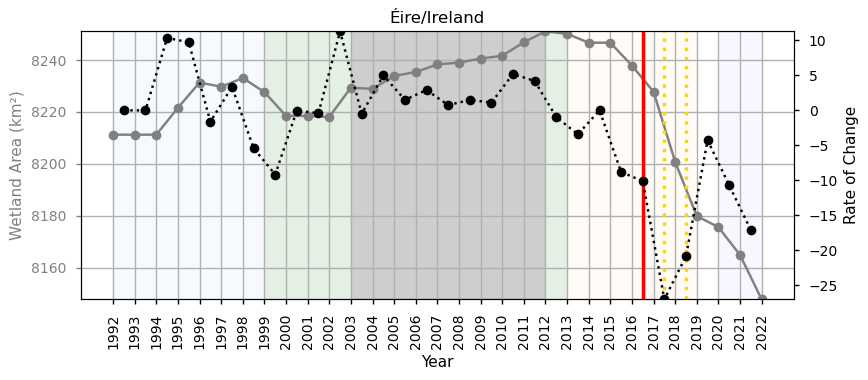

In [20]:
# Plot Breakpoints Series
n_rows = int(np.ceil(n_regions / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 5), squeeze=False)
axes = axes.flatten()

for idx, region in enumerate(unique_regions):
    ax = axes[idx]

    region_data = results_df[results_df["Region"] == region].sort_values("Year")
    years = region_data["Year"].to_numpy(dtype=float)
    wetland_Area = region_data["wetland_Area"].to_numpy(dtype=float)

    mono = monotonicity_metrics(wetland_Area)
    monotonicity_records.append({"Region": region, **mono})

    growth, growth_years = compute_growth(years, wetland_Area)
    spike_idx = detect_spikes(growth, spike_std_factor=spike_std_factor)
    breakpoint_idx = detect_breakpoints(
        growth,
        min_size=pelt_min_size,
        penalty=pelt_penalty,
        standardize=standardize_growth
    )

    spike_positions = growth_years[spike_idx] if len(spike_idx) else np.array([])
    breakpoint_positions = growth_years[breakpoint_idx] if len(breakpoint_idx) else np.array([])

    # Store spikes
    for s in spike_idx:
        rec = make_event_record(
            region, years, growth_years, s,
            extra={"Derivative": growth[s]}
        )
        spike_records.append(rec)
        update_counts(
            rec,
            interval_spike_counts,
            phase_spike_counts,
            prepost_spike_counts
        )

    # Store breakpoints
    for bp in breakpoint_idx:
        rec = make_event_record(region, years, growth_years, bp)
        breakpoint_records.append(rec)
        update_counts(
            rec,
            interval_breakpoint_counts,
            phase_breakpoint_counts,
            prepost_breakpoint_counts
        )

    # Background phases
    for phase in processing_phases:
        ax.axvspan(
            phase["start"],
            phase["end"],
            color=phase_colors.get(phase["label"], "lightgrey"),
            alpha=0.35,
            zorder=0
        )

    # Main series
    ax.plot(years, wetland_Area, marker="o", color="grey", zorder=2)
    ax.set_ylabel("Wetland Area (km²)", color="grey")
    ax.tick_params(axis="y", colors="grey")
    ax.set_ylim(global_y_min, global_y_max)

    # Breakpoints
    for x in breakpoint_positions:
        ax.axvline(
            x,
            color="red",
            linestyle="-",
            linewidth=2.5,
            zorder=4
        )

    # Spikes
    for x in spike_positions:
        ax.axvline(
            x,
            color="gold",
            linestyle=":",
            linewidth=2.5,
            zorder=5
        )

    # Growth rate
    ax2 = ax.twinx()
    ax2.plot(
        growth_years,
        growth,
        marker="o",
        linestyle="dotted",
        color="black",
        zorder=6
    )
    ax2.set_ylabel("Rate of Change", color="black")
    ax2.tick_params(axis="y", colors="black")
    ax2.set_ylim(global_derivative_min, global_derivative_max)

    # Formatting
    ax.set_xticks(years)
    ax.set_xticklabels(years.astype(int), rotation=90)
    ax.set_title(region)
    ax.set_xlabel("Year")
    ax.grid()

# Remove empty axes
for idx in range(n_regions, len(axes)):
    fig.delaxes(axes[idx])


# First reserve space above the plot
plt.tight_layout(rect=[0, 0, 1, 0.78])

# Get the actual plotted axis position after tight_layout
pos = axes[0].get_position()
legend_x = pos.x0 + pos.width / 2

# Build legend only from handles that actually exist

legend_handles = []

if "phase_handles" in globals():
    legend_handles += phase_handles

if "line_handles" in globals():
    legend_handles += line_handles

if len(legend_handles) > 0:
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(legend_x, 0.98),
        bbox_transform=fig.transFigure,
        ncol=4,
        frameon=True,
        fontsize=9
    )

plt.show()

To assess whether detected discontinuities in the wetland-area time series may be influenced by methodological factors, a targeted alignment analysis is performed. The aim is to evaluate whether **growth-rate breakpoints** and **derivative spikes** occur shortly after known **processing-chain changes**.

For each detected event, the time difference relative to each processing-change year is computed. An event is considered potentially related to a processing change only if it occurs **within the two years following that transition**. This forward-looking window reflects the temporal characteristics of the dataset, where land-cover changes are only confirmed if they persist over two consecutive years.

In addition to temporal alignment, the analysis also considers the **spatial consistency of detected signals**, quantified as the number of regions affected within a given interval. Methodological effects are expected to influence the dataset in a systematic way, and therefore to appear consistently across multiple regions. In contrast, signals affecting only a small number of regions are more likely to reflect **local dynamics** or region-specific variations rather than processing-related artefacts.

The results are summarised in **four complementary tables**, distinguishing between:

- **Event type**: breakpoints vs derivative spikes  
- **Analytical scope**: aligned vs full set of identified breakpoints and derivative spikes  

The first two tables report only events that occur **within two years after a processing transition**, while the two additional tables report **all detected events**.

In [ ]:
# Plot the aligned breakpoints and derivative spikes with known methodological changes present in more than half of the regions

sensors_timeline = {
    "GHSL_switch": [2000, 2003],
    "AVHRR_finish": [1999],
    "SPOT-VGT_start": [1999],
    "SPOT-VGT_finish": [2013],
    "MERIS_baseline_start": [2003],
    "MERIS_baseline_finish": [2012],
    "PROBAV_start": [2013],
    "S3_OLCI_start": [2020],
    "S3_OLCI_SLSTR_start": [2021],
}

forward_window = 2.0
min_regions = 10  # threshold for strong/systematic signal

breakpoint_df = pd.DataFrame(breakpoint_records)
spike_df = pd.DataFrame(spike_records)

def transition_interval_label(year, forward_window=2.0):
    start = int(year)
    end = int(year + forward_window)
    return f"{start}-{end}"

def summarize_by_transition_table(df, forward_window=2.0, min_regions=10):
    if df.empty:
        return pd.DataFrame(), False

    results = []
    any_aligned = False

    for transition_name, years in sensors_timeline.items():
        for transition_year in years:

            tmp = df.copy()
            tmp["Years_After"] = tmp["Year"] - transition_year

            aligned = tmp[
                (tmp["Years_After"] > 0) &
                (tmp["Years_After"] <= forward_window)
            ].copy()

            if aligned.empty:
                continue

            any_aligned = True

            regions = sorted(aligned["Region"].unique())

            if len(regions) < min_regions:
                continue

            intervals = sorted(aligned["Interval"].unique())

            results.append({
                "Interval": transition_interval_label(transition_year, forward_window),
                "Aligned signal intervals": ", ".join(intervals),
                "Number of regions": len(regions),
                "Region names": ", ".join(regions),
                "Nearest processing changes": transition_name,
            })

    if not results:
        return pd.DataFrame(), any_aligned

    summary = pd.DataFrame(results)

    summary = summary.sort_values(
        ["Interval", "Number of regions"],
        ascending=[True, False]
    ).reset_index(drop=True)

    return summary, any_aligned

def display_html_table(df):
    html = df.to_html(index=False, escape=False)
    display(HTML(html))

# Build tables
bp_summary, bp_any_aligned = summarize_by_transition_table(
    breakpoint_df,
    forward_window=forward_window,
    min_regions=min_regions
)

spike_summary, spike_any_aligned = summarize_by_transition_table(
    spike_df,
    forward_window=forward_window,
    min_regions=min_regions
)

# Display
print("### Breakpoint alignment table ###")
if bp_summary.empty:
    if bp_any_aligned:
        print(
            f"No breakpoint signals affect at least {min_regions} regions "
            f"within the known methodological changes transition windows"
        )
    else:
        print("No breakpoint signals are temporally aligned with any known methodological changes")
else:
    display_html_table(bp_summary)

print("\n### Derivative spike alignment table ###")
if spike_summary.empty:
    if spike_any_aligned:
        print(
            f"No derivative spike signals affect at least {min_regions} regions "
            f"within the known methodological changes transition windows"
        )
    else:
        print("No derivative spike signals are temporally aligned with any known methodological changes")
else:
    display_html_table(spike_summary)

### Breakpoint alignment table ###
No breakpoint signals are temporally aligned with any known methodological changes

### Derivative spike alignment table ###
No derivative spike signals are temporally aligned with any known methodological changes


In [ ]:
# Plot all breakpoints and derivative spikes 

def classify_transition_relation(year):
    matches = []
    for name, years in sensors_timeline.items():
        for t in years:
            if 0 < (year - t) <= forward_window:
                matches.append(f"{name} ({t})")
    return "; ".join(matches) if matches else "None within 2 years"


def build_summary(df):
    if df.empty:
        return pd.DataFrame(columns=[
            "intervals",
            "number of regions",
            "regions name",
            "nearest processing changes",
        ])

    summary = (
        df.groupby("Interval")
        .agg(
            **{
                "number of regions": ("Region", "nunique"),
                "regions name": ("Region", lambda x: ", ".join(sorted(set(x)))),
                "mean_year": ("Year", "mean"),
            }
        )
        .reset_index()
    )

    # Rename Interval column
    summary = summary.rename(columns={"Interval": "intervals"})

    # Add relation to processing transition
    summary["nearest processing changes"] = summary["mean_year"].apply(classify_transition_relation)

    # Drop helper column
    summary = summary.drop(columns=["mean_year"])

    # Sort by number of regions, then by interval
    summary = summary.sort_values(
        ["number of regions", "intervals"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return summary


# Build tables
bp_event_summary = build_summary(pd.DataFrame(breakpoint_records))
spike_event_summary = build_summary(pd.DataFrame(spike_records))

# Display nicely
pd.set_option("display.max_colwidth", None)

print("### Breakpoint Table ###")
display(bp_event_summary)

print("### Derivative Spike Table ###")
display(spike_event_summary)

### Breakpoint Table ###


,intervals,number of regions,regions name,nearest processing changes
0,2016-2017,1,Éire/Ireland,None within 2 years


### Derivative Spike Table ###


,intervals,number of regions,regions name,nearest processing changes
0,2017-2018,1,Éire/Ireland,None within 2 years
1,2018-2019,1,Éire/Ireland,None within 2 years


#### Breakpoint Analysis

Breakpoint detection and derivative analysis capture two complementary aspects of temporal dynamics in land cover time series, a distinction widely recognised in change detection literature ([Chelali et al., 2019](https://doi.org/10.1109/JURSE.2019.8808967); [Chang et al., 2018](https://doi.org/10.1088/1755-1315/113/1/012087)):

- **Breakpoints** identify the onset of structural changes in the time series  
- **Derivative spikes** highlight years of maximum year-to-year variation  

Because of this, spikes may occur slightly after breakpoints, reflecting the difference between **initiation** and **peak expression** of change ([Chelali et al., 2019](https://doi.org/10.1109/JURSE.2019.8808967)).

The interpretation is guided by **temporal alignment with processing-chain transitions**. This is particularly important in satellite-derived land cover products, where methodological updates (e.g. sensor transitions, classification schemes, or reference layers) can introduce artificial discontinuities in time series.  

A signal affecting many regions simultaneously is more likely to reflect a **systematic driver** (either methodological or large-scale real dynamics), whereas signals affecting few regions are more likely **local effects** ([Chang et al., 2018](https://doi.org/10.1088/1755-1315/113/1/012087)).

---

**Breakpoint ~2016–2017**

A  breakpoint is detected in the Irish wetland-area time series during the **2016–2017** interval. This marks the clearest structural change in the national series. Prior to this point, mapped wetland area remains relatively stable, with only moderate interannual variability. After 2016–2017, the trajectory shifts toward a sustained decline.

The breakpoint is supported by concurrent short-term rate-of-change signals. The derivative-spike analysis identifies strong negative changes in **2017–2018** and **2018–2019**, indicating that the structural shift was followed by a period of increased short-term variability and rapid decline in mapped wetland area.

Importantly, the breakpoint table indicates **no temporal alignment with an identified processing-chain transition within the ±2-year window**, reducing the likelihood that this signal is methodological.

This pattern provides evidence for a **candidate structural shift in mapped wetland dynamics in Ireland**. The combination of a detected breakpoint, subsequent derivative spikes, and lack of alignment with identified processing-chain changes suggests that the signal may reflect real changes in wetland or peatland condition rather than a simple artefact.

A plausible interpretation is that the breakpoint captures a period of changing peatland and wetland trajectories associated with **drainage status, peat extraction decline, post-industrial peatland after-use, and emerging restoration activity**. Irish peatlands have experienced substantial land-use change, including conversion to grassland, forestry, extraction, and other managed uses, which can alter both hydrology and mapped land-cover class ([Habib & Connolly, 2023](https://doi.org/10.1007/s10113-023-02116-0); [Tuohy et al., 2023](https://doi.org/10.1016/j.jenvman.2023.118391); [Habib et al., 2024](https://doi.org/10.1038/s41598-024-51660-0)).

The post-2016 decline may therefore represent a combination of:

- Continued effects of **peatland drainage and land-use intensification**, especially where wetland or semi-natural peatland areas become spectrally closer to grassland, shrubland, or other drier classes ([Tuohy et al., 2023](https://doi.org/10.1016/j.jenvman.2023.118391); [Bari et al., 2025](https://doi.org/10.30955/gnc2025.00123));  
- **Post-extraction vegetation change** in cutaway and cutover bogs, where rewetting, scrub colonisation, open-water formation, or wet grassland development may produce heterogeneous land-cover signals ([Crowley et al., 2022](https://doi.org/10.3318/bioe.2021.09); [Räsänen et al., 2023](https://doi.org/10.1016/j.scitotenv.2023.163583));  
- Localised effects of **peatland rehabilitation and rewetting**, which can rapidly alter hydrology, vegetation, and carbon dynamics but may not always map directly into a single wetland class at 300 m resolution ([Renou-Wilson et al., 2019](https://doi.org/10.1016/j.ecoleng.2018.02.014); [Aitova et al., 2025](https://doi.org/10.3390/land14112226));  
- Broader policy and restoration momentum during the late 2010s and early 2020s, when peatland restoration became increasingly linked to climate mitigation, biodiversity recovery, and land-use transition ([Farrell et al., 2024](https://doi.org/10.1111/rec.14216); [Tanneberger et al., 2020](https://doi.org/10.1002/adsu.202000146)).

Overall, the **2016–2017 breakpoint** is best interpreted as the onset of a new wetland-area regime in the mapped C3S series. The subsequent derivative spikes in **2017–2018** and **2018–2019** indicate that this transition was not only structural, but was also followed by abrupt year-to-year reductions in mapped wetland area.

---

**Derivative spike ~2017–2018**

A strong negative derivative spike is detected during **2017–2018**, immediately after the main 2016–2017 breakpoint. This indicates a sharp year-to-year decline in mapped wetland area.

Because this spike follows the main breakpoint, it is interpreted as part of the same transition rather than as an isolated anomaly. It may represent the rapid expression of land-cover reclassification following hydrological or vegetation change, particularly in peatland landscapes where drainage, drying, rewetting, vegetation recovery, scrub development, or post-extraction after-use can alter spectral signatures over short periods.

This interpretation is consistent with evidence that Irish peatland condition and land-use class are strongly influenced by drainage networks, drainage effectiveness, and peatland-use type ([Tuohy et al., 2023](https://doi.org/10.1016/j.jenvman.2023.118391); [Habib et al., 2024](https://doi.org/10.1002/rse2.387); [Atapattu et al., 2023](https://doi.org/10.3390/land12081614)). However, the spike should not be interpreted automatically as direct wetland loss without spatial validation, because wetland and peatland transitions may involve changes among flooded vegetation, grassland, shrubland, sparse vegetation, forest, and open-water classes.

---

 **Derivative spike ~2018–2019**

A second negative derivative spike is detected during **2018–2019**, indicating that the decline in mapped wetland area continued beyond the initial post-breakpoint year.

The persistence of negative derivative signals across consecutive intervals strengthens the interpretation of a **sustained post-breakpoint decline**, rather than a single-year classification anomaly. This pattern suggests that the wetland time series entered a new trajectory after 2016–2017.

Potential drivers include continued drainage effects, changes in peatland land use, vegetation succession on cutover peatlands, forestry or scrub encroachment, and spatially variable rewetting outcomes. Studies of restored and rewetted Irish raised bogs show that hydrological recovery and vegetation response can be uneven, with carbon and vegetation dynamics changing rapidly after restoration but varying according to site condition and management history ([Renou-Wilson et al., 2019](https://doi.org/10.1016/j.ecoleng.2018.02.014); [Crowley et al., 2022](https://doi.org/10.3318/bioe.2021.09); [Aitova et al., 2025](https://doi.org/10.3390/land14112226)).

---

**Overall interpretation**

The Irish wetland-area series shows one dominant breakpoint cluster around **2016–2017**, followed by strong negative derivative spikes in **2017–2018** and **2018–2019**. This sequence indicates a transition from relative stability to sustained decline in mapped wetland area.

The signal is strongest because:

- The main breakpoint occurs at the start of a clear post-2016 decline;
- The following two intervals show strong negative rate-of-change spikes;
- No processing-chain transition is identified within the ±2-year window in the breakpoint summary table;
- The timing is consistent with a period of major change in Irish peatland management, including declining industrial peat extraction, increasing restoration activity, and growing policy emphasis on peatlands for climate and biodiversity objectives ([Farrell et al., 2024](https://doi.org/10.1111/rec.14216); [Habib & Connolly, 2023](https://doi.org/10.1007/s10113-023-02116-0); [Räsänen et al., 2023](https://doi.org/10.1016/j.scitotenv.2023.163583)).

Nevertheless, the result should be treated as a **candidate land-cover transition** rather than definitive evidence of ecological wetland loss. In Ireland, peatlands and mapped wetlands are not equivalent: degraded, drained, afforested, or agriculturally managed peatlands may be classified as grassland, shrubland, sparse vegetation, forest, or other land-cover types rather than wetland.

(code-section-4)=
### **4.Trend Assessment**

The next and final step is to determine whether the trend should be computed for the entire period (total trend) or divided into segments based on detected breakpoints.

The decision between using the total trend or segmented trends is based on Sen’s Slope (Trend Magnitude) and Mann-Kendall p-values (Trend Significance). Sen’s Slope is a non-parametric estimator that calculates the median rate of change over time. First, Sen’s Slope is computed for the total trend, capturing the overall rate of wetland change. Then, Sen’s Slope is calculated for each segmented trend to assess whether breakpoints introduce significant shifts in trend magnitude. The Mann-Kendall test is a non-parametric statistical test used to assess the presence of an upward or downward trend in a time series without requiring the data to follow any particular distribution. In parallel, the Mann-Kendall p-value is evaluated for both the total and segmented trends to measure trend significance - lower p-values indicate stronger evidence of a significant trend.

The final decision is based on the following approach:

- If segmented trends show substantially different Sen’s Slopes compared to the total trend and exhibit stronger statistical significance (lower p-values), segmentation is preferred.
- If segmented trends closely resemble the total trend or do not provide a clear statistical advantage, the total trend is used to maintain a simpler and more robust interpretation.

In [ ]:
# Prepare data for trend calculation

breakpoints_df = pd.DataFrame(breakpoint_records).copy()
breakpoints_df["Year"] = pd.to_numeric(breakpoints_df["Year"], errors="coerce").round().astype("Int64")

results_df = results_df.copy()
results_df["Year"] = pd.to_numeric(results_df["Year"], errors="coerce")
results_df["wetland_Area"] = pd.to_numeric(results_df["wetland_Area"], errors="coerce")

# Keep only valid rows
results_df = results_df.dropna(subset=["Region", "Year", "wetland_Area"]).copy()
breakpoints_df = breakpoints_df.dropna(subset=["Region", "Year"]).copy()

In [ ]:
# Calculate trends

def mann_kendall_p(x):
    """Return Mann-Kendall p-value and trend label."""
    if len(x) < 3:
        return np.nan, "no trend"
    res = mk.original_test(x)
    return res.p, res.trend

def significance_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

def significance_traffic_light(p):
    if pd.isna(p):
        return "Unknown"
    if p < 0.05:
        return "Green"
    elif p < 0.10:
        return "Amber"
    return "Red"

def trend_direction(rate_per_decade, p_value, stable_threshold=0.10):
    """
    Classify overall direction.
    stable_threshold is in percentage points of area per decade.
    """
    if pd.isna(rate_per_decade):
        return "Unknown"
    if (not pd.isna(p_value) and p_value >= 0.05) or abs(rate_per_decade) < stable_threshold:
        return "Stable"
    return "Increase" if rate_per_decade > 0 else "Decrease"

def material_segmentation_change(total_direction, total_rate_decade, segment_rows):
    """
    Returns Yes if at least one significant segment changes the conclusion materially.
    Conservative logic:
    - any significant segment with opposite direction to total
    - OR strongest significant segment is >1.5x total magnitude and opposite sign
    """
    if segment_rows.empty:
        return "No"
    
    sig = segment_rows[segment_rows["MK_P_Value"] < 0.05].copy()
    if sig.empty:
        return "No"
    
    for _, r in sig.iterrows():
        seg_dir = r["Direction"]
        if total_direction in ["Increase", "Decrease"] and seg_dir in ["Increase", "Decrease"]:
            if seg_dir != total_direction:
                return "Yes"
    
    return "No"

def confidence_label(n_breakpoints, segmentation_changes, total_p, total_rate_decade):
    """
    Reviewer asks for confidence considering breakpoints and local drivers.
    Since local drivers are not encoded in this table, use a transparent rule:
    - High: significant total trend, no material segmentation change, <=1 breakpoint
    - Medium: significant total trend but segmentation change or multiple breakpoints
    - Low: non-significant total trend or unstable segmented interpretation
    """
    if pd.isna(total_p):
        return "Low"
    if total_p >= 0.05:
        return "Low"
    if segmentation_changes == "No" and n_breakpoints <= 1:
        return "High"
    return "Medium"


# Compute total + segmented trends 

trend_records = []

for region in results_df["Region"].dropna().unique():
    region_data = results_df.loc[results_df["Region"] == region].sort_values("Year").copy()
    X_total = region_data["Year"].values
    y_total = region_data["wetland_Area"].values

    if len(region_data) < 3 or np.isnan(y_total).any():
        continue

    # Total Sen slope
    total_sen_slope, _, _, _ = theilslopes(y_total, X_total)

    # Convert to % area per decade, as requested by reviewer
    mean_total_area = np.mean(y_total)
    total_rate_pct_per_year = (total_sen_slope / mean_total_area) * 100 if mean_total_area != 0 else np.nan
    total_rate_pct_per_decade = total_rate_pct_per_year * 10 if pd.notna(total_rate_pct_per_year) else np.nan

    # Mann-Kendall
    total_p_value, total_mk_trend = mann_kendall_p(y_total)
    total_direction = trend_direction(total_rate_pct_per_decade, total_p_value)

    trend_records.append({
        "Region": region,
        "Type": "Total",
        "Start_Year": int(region_data["Year"].min()),
        "End_Year": int(region_data["Year"].max()),
        "Sen_Slope": round(total_sen_slope, 6),
        "Rate_of_Change_pct_per_year": round(total_rate_pct_per_year, 6) if pd.notna(total_rate_pct_per_year) else np.nan,
        "Rate_of_Change_pct_per_decade": round(total_rate_pct_per_decade, 6) if pd.notna(total_rate_pct_per_decade) else np.nan,
        "MK_P_Value": total_p_value,
        "MK_Trend": total_mk_trend,
        "Direction": total_direction,
        "Significance_Stars": significance_stars(total_p_value),
        "Traffic_Light": significance_traffic_light(total_p_value),
        "Segment_Length": len(region_data)
    })

    # Breakpoints and segmented trends
    region_breakpoints = (
        breakpoints_df.loc[breakpoints_df["Region"] == region, "Year"]
        .dropna()
        .astype(int)
        .tolist()
    )
    bounds = sorted(set([int(region_data["Year"].min())] + region_breakpoints + [int(region_data["Year"].max())]))

    for i in range(len(bounds) - 1):
        start_year, end_year = bounds[i], bounds[i + 1]
        segment_data = region_data[(region_data["Year"] >= start_year) & (region_data["Year"] <= end_year)].copy()

        if len(segment_data) < 3:
            continue

        X_seg = segment_data["Year"].values
        y_seg = segment_data["wetland_Area"].values

        seg_sen_slope, _, _, _ = theilslopes(y_seg, X_seg)

        mean_seg_area = np.mean(y_seg)
        seg_rate_pct_per_year = (seg_sen_slope / mean_seg_area) * 100 if mean_seg_area != 0 else np.nan
        seg_rate_pct_per_decade = seg_rate_pct_per_year * 10 if pd.notna(seg_rate_pct_per_year) else np.nan

        seg_p_value, seg_mk_trend = mann_kendall_p(y_seg)
        seg_direction = trend_direction(seg_rate_pct_per_decade, seg_p_value)

        trend_records.append({
            "Region": region,
            "Type": "Segmented",
            "Start_Year": int(start_year),
            "End_Year": int(end_year),
            "Sen_Slope": round(seg_sen_slope, 6),
            "Rate_of_Change_pct_per_year": round(seg_rate_pct_per_year, 6) if pd.notna(seg_rate_pct_per_year) else np.nan,
            "Rate_of_Change_pct_per_decade": round(seg_rate_pct_per_decade, 6) if pd.notna(seg_rate_pct_per_decade) else np.nan,
            "MK_P_Value": seg_p_value,
            "MK_Trend": seg_mk_trend,
            "Direction": seg_direction,
            "Significance_Stars": significance_stars(seg_p_value),
            "Traffic_Light": significance_traffic_light(seg_p_value),
            "Segment_Length": len(segment_data)
        })

trends_df = pd.DataFrame(trend_records)

The following summary table reports:

- **Growth rate (%/decade)** → long-term rate of wetland expansion  
- **Significance** → statistical robustness of the full trend 
    - `***` → highly significant (p < 0.001)  
    - `**` → significant (p < 0.01)  
    - `*` → moderately significant (p < 0.05)  
    - no symbol → not statistically significant  
- **Breakpoints** → number of structural changes detected  
- **Segmented trend needed?** → whether segmented trends change the interpretation  
- **Confidence** → degree of agreement between full and segmented trend significance  

In [ ]:
# Build summary table

summary_rows = []

latest_year = results_df["Year"].astype(int).max()

# wetland area for each region in the latest year
area_per_region = (
    results_df.loc[results_df["Year"].astype(int) == latest_year, ["Region", "wetland_Area"]]
    .drop_duplicates(subset=["Region"])
    .set_index("Region")["wetland_Area"]
)

def confidence_label(total_p_value, segment_rows):
    """
    Confidence based on agreement between the significance
    of the full trend and the segmented trends.

    Rules:
    - Low: full trend is not significant
    - High: full trend is significant and all segmented trends are significant
    - Medium: full trend is significant but segmented trends are mixed or weaker
    """
    if pd.isna(total_p_value):
        return "Low"

    if total_p_value >= 0.05:
        return "Low"

    if segment_rows.empty:
        return "High"

    valid_segments = segment_rows.dropna(subset=["MK_P_Value"]).copy()

    if valid_segments.empty:
        return "High"

    sig_segments = valid_segments[valid_segments["MK_P_Value"] < 0.05]
    nonsig_segments = valid_segments[valid_segments["MK_P_Value"] >= 0.05]

    if len(sig_segments) == len(valid_segments):
        return "High"

    if len(sig_segments) > 0 and len(nonsig_segments) > 0:
        return "Medium"

    return "Medium"


for region in trends_df["Region"].unique():
    total_row = trends_df[
        (trends_df["Region"] == region) & (trends_df["Type"] == "Total")
    ].iloc[0]

    segment_rows = trends_df[
        (trends_df["Region"] == region) & (trends_df["Type"] == "Segmented")
    ].copy()

    n_breakpoints = breakpoints_df.loc[
        breakpoints_df["Region"] == region, "Year"
    ].nunique()

    seg_changes = material_segmentation_change(
        total_direction=total_row["Direction"],
        total_rate_decade=total_row["Rate_of_Change_pct_per_decade"],
        segment_rows=segment_rows
    )

    confidence = confidence_label(
        total_p_value=total_row["MK_P_Value"],
        segment_rows=segment_rows
    )

    summary_rows.append({
        "Region": region,
        "Total wetland area (km²)": area_per_region.get(region, np.nan),
        "Growth rate (%/decade)": total_row["Rate_of_Change_pct_per_decade"],
        "Significance": total_row["Significance_Stars"],
        "Breakpoints": int(n_breakpoints) if pd.notna(n_breakpoints) else 0,
        "Segmented trend needed?": seg_changes,
        "Confidence": confidence
    })

executive_summary_df = pd.DataFrame(summary_rows)

# Sort by growth rate
executive_summary_df = executive_summary_df.sort_values(
    "Growth rate (%/decade)", ascending=False
).reset_index(drop=True)

# Round for display
executive_summary_df["Growth rate (%/decade)"] = executive_summary_df["Growth rate (%/decade)"].round(1)
executive_summary_df["Total wetland area (km²)"] = executive_summary_df["Total wetland area (km²)"].round(0)

# Normalize text values
executive_summary_df["Segmented trend needed?"] = executive_summary_df["Segmented trend needed?"].map({
    "Yes": "Yes",
    "No": "No"
}).fillna("No")

executive_summary_df["Confidence"] = executive_summary_df["Confidence"].fillna("Low")
executive_summary_df["Significance"] = executive_summary_df["Significance"].fillna("")

n_regions = len(executive_summary_df)
n_seg_no = (executive_summary_df["Segmented trend needed?"] == "No").sum()
n_high = (executive_summary_df["Confidence"] == "High").sum()
n_medium = (executive_summary_df["Confidence"] == "Medium").sum()
n_low = (executive_summary_df["Confidence"] == "Low").sum()

print(
    f"{n_regions} regions were assessed. "
    f"Segmented trends are not required in {n_seg_no} of {n_regions} regions. "
    f"Confidence is High in {n_high} regions, Medium in {n_medium}, and Low in {n_low}."
)


# HTML table display

def color_significance(val):
    if val == "***":
        return "background-color: #e2f0d9; color: #1f4d1f; font-weight: bold;"
    elif val == "**":
        return "background-color: #fff2cc; color: #7f6000; font-weight: bold;"
    elif val == "*":
        return "background-color: #fce5cd; color: #7f3f00; font-weight: bold;"
    return ""

def color_segmented(val):
    if val == "No":
        return "background-color: #e2f0d9; color: #1f4d1f; font-weight: bold;"
    elif val == "Yes":
        return "background-color: #f4cccc; color: #990000; font-weight: bold;"
    return ""

def color_confidence(val):
    if val == "High":
        return "background-color: #d9ead3; color: #1f4d1f; font-weight: bold;"
    elif val == "Medium":
        return "background-color: #fff2cc; color: #7f6000; font-weight: bold;"
    elif val == "Low":
        return "background-color: #f4cccc; color: #990000; font-weight: bold;"
    return ""

def growth_bar(val, vmin, vmax):
    if pd.isna(val):
        return ""
    pct = 100 if vmax == vmin else 100 * (val - vmin) / (vmax - vmin)
    return f"background: linear-gradient(90deg, #9fc5e8 {pct:.1f}%, transparent {pct:.1f}%); text-align: center;"

def display_executive_summary_table(df):
    df_display = df.copy()
    vmin = df_display["Growth rate (%/decade)"].min()
    vmax = df_display["Growth rate (%/decade)"].max()

    def style_row(row):
        styles = []
        for col, val in row.items():
            base = "padding: 6px 8px; border: 1px solid #ccc;"
            if col == "Region":
                base += " text-align: left; font-weight: bold;"
            else:
                base += " text-align: center;"

            if col == "Significance":
                base += color_significance(val)
            elif col == "Segmented trend needed?":
                base += color_segmented(val)
            elif col == "Confidence":
                base += color_confidence(val)
            elif col == "Growth rate (%/decade)":
                base += growth_bar(val, vmin, vmax)

            styles.append(base)
        return styles

    styled = df_display.style.format({
        "Total wetland area (km²)": "{:.0f}",
        "Growth rate (%/decade)": "{:.1f}"
    }).apply(style_row, axis=1)

    html = styled.to_html()

    wrapped_html = f"""
    <div style="overflow-x:auto;">
        <style>
            table {{
                border-collapse: collapse;
                width: 100%;
                font-size: 13px;
            }}
            th {{
                background-color: #f2f2f2;
                border: 1px solid #ccc;
                padding: 6px 8px;
                text-align: center;
            }}
        </style>
        {html}
    </div>
    """

    display(HTML(wrapped_html))

display_executive_summary_table(executive_summary_df)

1 regions were assessed. Segmented trends are not required in 1 of 1 regions. Confidence is High in 0 regions, Medium in 0, and Low in 1.


,Region,Total wetland area (km²),Growth rate (%/decade),Significance,Breakpoints,Segmented trend needed?,Confidence
0,Éire/Ireland,8148,0.1,,1,No,Low


#### Trend Analysis 

The trend analysis indicates a very weak long-term increase in mapped wetland area over the 1992–2022 period. The estimated growth rate is approximately 0.1% per decade, based on a total mapped wetland area of around 8,148 km². This suggests that, at the national scale, the wetland time series is broadly stable, with only a marginal positive trend over the full observation period.

Although one breakpoint was detected, the trend-selection procedure indicates that a segmented trend is not required. This means that the breakpoint does not provide sufficient evidence to justify replacing the full-period trend with separate pre- and post-breakpoint trends. In other words, while the breakpoint highlights a change in the temporal structure of the series, it does not substantially improve the statistical or interpretative value of the trend estimate.

This result suggests that the full-period trend remains the most appropriate summary of national wetland dynamics in the Lc dataset. The detected breakpoint around 2016–2017, together with the negative derivative spikes in 2017–2018 and 2018–2019, points to a short-term disturbance or transition in the time series. However, this disturbance is not strong enough to alter the overall trend recommendation.

The confidence level is classified as low, which is important for interpretation. This low confidence likely reflects the combination of a very small growth rate, limited statistical strength, and the presence of a breakpoint without a clear need for segmentation. Therefore, the result should not be interpreted as strong evidence of national wetland expansion. Instead, it indicates a largely stable national wetland signal, with some post-2016 decline visible in the time series but not sufficient to change the full-period trend classification.

Overall, the analysis supports the use of the total trend as the preferred national-scale estimate for Ireland. Segmentation remains useful as a diagnostic tool for identifying temporal deviations, especially around 2016–2019, but the full-period trend provides the most methodologically stable representation of the mapped wetland trajectory. For spatial planning and land management applications, this means that the national series should be interpreted as showing near-stability rather than robust wetland growth or decline. More detailed spatial analysis is needed to determine whether local peatland drainage, restoration, afforestation, cutaway bog rehabilitation, or hydrological change produced contrasting regional patterns that are masked in the national aggregate.

(code-section-5)=
### **5. Discussion**

The analysis demonstrates that the C3S LC is suitable for broad, long-term assessment of wetland-related land-cover dynamics in Ireland. Its multi-decadal coverage provides a useful basis for identifying overall temporal patterns, while the breakpoint and derivative analyses help highlight periods where the time series departs from its longer-term behaviour.

For spatial planning and land management, this type of dataset is most valuable as a screening and monitoring tool. It can support the identification of broad national or regional patterns, guide further investigation, and help place recent wetland changes in a longer historical context. However, it should not be treated as a substitute for site-level wetland inventories, ecological surveys, or high-resolution hydrological assessment.

The results also highlight the need for careful interpretation of mapped wetland change. Wetland systems are dynamic, and changes in mapped extent may reflect a mixture of ecological, hydrological, land-use, and methodological factors. In particular, variations in surface wetness, vegetation condition, drainage, restoration, or seasonal water levels can influence how wetlands are represented in annual land-cover products.

The presence of breakpoints should therefore be interpreted as an indication of periods requiring closer examination, rather than as direct evidence of a single causal process. Breakpoint analysis is useful for identifying possible shifts in the time series, but attribution requires additional contextual information, including land management history, restoration records, climate variability, protected-area status, and higher-resolution spatial data.

Overall, the dataset provides a consistent and practical foundation for assessing wetland land-cover trends at broad spatial scales. Its main strength lies in its long temporal coverage and standardised classification framework. For operational applications, the most robust approach is to use the full-period trend as a general indicator, while using breakpoint and segmentation outputs to flag periods or areas where more detailed validation is required.

## ℹ️ If you want to know more

### Key Resources

* The CDS catalogue entry for the data used was [Land cover classification gridded maps from 1992 to present derived from satellite observations](https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=overview)

* Product User Guide and Specification of the dataset [version 2.1](https://dast.copernicus-climate.eu/documents/satellite-land-cover/D5.3.1_PUGS_ICDR_LC_v2.1.x_PRODUCTS_v1.1.pdf) and [version 2.0](https://dast.copernicus-climate.eu/documents/satellite-land-cover/D3.3.11-v1.0_PUGS_CDR_LC-CCI_v2.0.7cds_Products_v1.0.1_APPROVED_Ver1.pdf) 

* [Eurostat NUTS](https://ec.europa.eu/eurostat/web/nuts) (Nomenclature of territorial units for statistics)

* [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), c3s_eqc_automatic_quality_control, prepared by [B-Open](https://www.bopen.eu/)




### References

* [Aitova, E., Renou-Wilson, F., Wilson, D., Crowley, W., & Morley, T. R. (2025). Immediate impact of rewetting on carbon dynamics in a degraded Irish raised bog. *Land, 14*(11), 2226.](https://doi.org/10.3390/land14112226)

* [Atapattu, A. J., et al. (2023). Effect of ‘peatland-use’ type on culturable microbial groups in Irish peatlands. *Land, 12*(8), 1614.](https://doi.org/10.3390/land12081614)

* [Bari, M. A., et al. (2025). Assessment and mapping of the drainage status of Ireland’s peatlands. *CEST2025*.](https://doi.org/10.30955/gnc2025.00123)

* [Bord na Móna. (n.d.). Peatland restoration.](https://www.bnm.ie/peatlands/peatland-restoration/)

* [Chang, Y., Hou, K., Li, X., Zhang, Y., & Chen, P. (2018). Review of land use and land cover change research progress. *IOP Conference Series: Earth and Environmental Science, 113*, 012087.](https://doi.org/10.1088/1755-1315/113/1/012087)

* [Chelali, M., Kurtz, C., Puissant, A., & Vincent, N. (2019). Urban land cover analysis from satellite image time series based on temporal stability. *Joint Urban Remote Sensing Event (JURSE), 2019*, 1–4.](https://doi.org/10.1109/JURSE.2019.8808967)

* [Climate Data Store. (n.d.). Land cover classification gridded maps from 1992 to present derived from satellite observations.](https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=overview)

* [Coillte. (n.d.). Nature conservation projects.](https://www.coillte.ie/our-business/our-projects/nature-conservation/)

* [Crowley, W., Smith, G. F., Mackin, F., Regan, S., Fernandez Valverde, F., & Eakin, M. (2021). Recovery of the vegetation of a cutover raised bog in Ireland following rewetting measures. *Biology and Environment: Proceedings of the Royal Irish Academy, 121B*(2), 95–121.](https://doi.org/10.3318/bioe.2021.09)

* [Department of Arts, Heritage and the Gaeltacht. (2015). *National Peatlands Strategy*.](https://www.npws.ie/sites/default/files/general/Final%20National%20Peatlands%20Strategy.pdf)

* [Environmental Protection Agency. (2020). *Saltmarsh monitoring and assessment research report*.](https://www.epa.ie/publications/research/water/Research_Report_313.pdf)

* [Environmental Protection Agency. (2023). *Research report on drought and water-related environmental impacts in Ireland*.](https://www.epa.ie/publications/research/water/EPA-Report-SinglePage-446.pdf)

* [Environmental Protection Agency. (2024). *Drinking water quality in public supplies 2024*.](https://www.epa.ie/publications/compliance--enforcement/drinking-water/annual-drinking-water-reports/FINAL-EPA_DrinkingWaterQualityinPublicSupplies2024-v1.4.pdf)

* [Environmental Protection Agency. (2025). *Bord na Móna rehabilitation and peatland restoration documentation*.](https://leap.epa.ie/docs/0bb0df04-15a7-471e-9d16-d258233d5c06.pdf)

* [European Commission LIFE Programme. (n.d.). Restoring active blanket bog in Ireland.](https://webgate.ec.europa.eu/life/publicWebsite/project/LIFE02-NAT-IRL-008490/restoring-active-blanket-bog-in-ireland)

* [European Commission. (2021). *New EU Forest Strategy for 2030*.](https://commission.europa.eu/document/cf3294e1-8358-4c93-8de4-3e1503b95201_en)

* [Eurostat. (2022). Forests, forestry and logging. *Statistics Explained*.](https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Forests,_forestry_and_logging)

* [Farrell, C. A., Connolly, J., & Morley, T. R. (2024). Charting a course for peatland restoration in Ireland: A case study to support restoration frameworks in other regions. *Restoration Ecology*.](https://doi.org/10.1111/rec.14216)

* [Geological Survey Ireland. (n.d.). National Coastal Change Assessment.](https://www.gsi.ie/en-ie/programmes-and-projects/marine-and-coastal-unit/projects/Pages/National-Coastal-Change-Assessment.aspx)

* [Government of Ireland. (2020). Bord na Móna Bog Rehabilitation Scheme.](https://www.gov.ie/en/department-of-climate-energy-and-the-environment/publications/bord-na-m%C3%B3na-bog-rehabilitation-scheme/)

* [Government of Ireland. (2023). National Peatlands Strategy: Mid-Term Review and Implementation Plan.](https://www.gov.ie/en/department-of-housing-local-government-and-heritage/publications/national-peatlands-strategy-mid-term-review-and-implementation-plan/)

* [Habib, W., & Connolly, J. (2023). A national-scale assessment of land use change in peatlands between 1989 and 2020 using Landsat data and Google Earth Engine: A case study of Ireland.](https://doi.org/10.1007/s10113-023-02116-0)

* [Habib, W., Cresson, R., McGuinness, K., & Connolly, J. (2024). Mapping artificial drains in peatlands: A national-scale assessment of Irish raised bogs using sub-meter aerial imagery and deep learning methods. *Remote Sensing in Ecology and Conservation, 10*(4), 551–562.](https://doi.org/10.1002/rse2.387)

* [Habib, W., Ingle, R., Saunders, M., & Connolly, J. (2024). Quantifying peatland land use and CO₂ emissions in Irish raised bogs: Mapping insights using Sentinel-2 data and Google Earth Engine. *Scientific Reports, 14*, 1171.](https://doi.org/10.1038/s41598-024-51660-0)

* [Healy, M. G., & Hickey, K. R. (2002). Historic land reclamation and intertidal wetland change in the Shannon Estuary, Ireland. *Journal of Coastal Research, 36*, 365–373.](https://doi.org/10.2112/1551-5036-36.sp1.365)

* [Irish Peatland Conservation Council. (2020). Habitat loss of peatlands.](https://www.ipcc.ie/a-to-z-peatlands/irelands-peatland-conservation-action-plan/peatland-action-plan/habitat-loss-of-peatlands/)

* [Irish Peatland Conservation Council. (n.d.). Restoration of burned peatlands.](https://www.ipcc.ie/advice/peatland-management-diy-tool-kit/restoration-of-burned-peatlands/)

* [IUCN UK Peatland Programme. (2024). *State of UK Peatlands*.](https://www.iucn-uk-peatlandprogramme.org/sites/default/files/2024-06/State%20of%20UK%20Peatlands.pdf)

* [Jovani-Sancho, A. J., Cummins, T., & Byrne, K. A. (2021). Soil carbon balance of afforested peatlands in the maritime temperate climatic zone. *Global Change Biology, 27*(15), 3681–3698.](https://doi.org/10.1111/gcb.15654)

* [Jurasinski, G., et al. (2024). Active afforestation of drained peatlands is not a viable restoration option under the EU Nature Restoration Law. *Ambio*.](https://doi.org/10.1007/s13280-024-02016-5)

* [Mander, Ü., Espenberg, M., Melling, L., & Kull, A. (2023). Peatland restoration pathways to mitigate greenhouse gas emissions and retain peat carbon. *Biogeochemistry*.](https://doi.org/10.1007/s10533-023-01103-1)

* [McCormack, T., Campanyà, J., & Naughton, O. (2023). Reconstructing flood level timeseries at seasonal wetlands in Ireland using Sentinel-1. *Remote Sensing of Environment, 299*, 113839.](https://doi.org/10.1016/j.rse.2023.113839)

* [Möller, I., et al. (2021). Salt marsh resilience to sea-level rise and increased storm intensity. *Geomorphology*.](https://doi.org/10.1016/j.geomorph.2021.107847)

* [Natura Communities. (n.d.). Threats to protected habitats.](https://www.naturacommunities.ie/protecting-and-restoring/threats/)

* [National Parks and Wildlife Service. (2017). Site-specific conservation objectives data.](https://www.npws.ie/maps-and-data/designated-site-data/ssco-data)

* [Raised Bog Restoration Ireland. (n.d.). Raised bog restoration in Ireland.](https://raisedbogs.ie/)

* [Räsänen, A., et al. (2023). After-use of peat extraction sites: A systematic review of biodiversity, climate, hydrological and social impacts. *Science of the Total Environment, 882*, 163583.](https://doi.org/10.1016/j.scitotenv.2023.163583)

* [Renou-Wilson, F., Moser, G., Fallon, D., Farrell, C. A., Müller, C., & Wilson, D. (2019). Rewetting degraded peatlands for climate and biodiversity benefits: Results from two raised bogs. *Ecological Engineering, 127*, 547–560.](https://doi.org/10.1016/j.ecoleng.2018.02.014)

* [Shamsuzzaman, M., et al. (2025). Restoration of a degraded raised bog: Implications for carbon flux and hydrological recovery. *ARPHA Conference Abstracts, 8*.](https://doi.org/10.3897/aca.8.e148818)

* [Tähtikarhu, M., Räsänen, T. A., Hyväluoma, J., Piayda, A., & Myllys, M. (2025). Analysing hydrological impacts of controlled drainage, peat thickness and groundwater fluxes in cultivated peat soils. *Acta Agriculturae Scandinavica, Section B — Soil & Plant Science, 75*(1).](https://doi.org/10.1080/09064710.2025.2454388)

* [Tanneberger, F., Appulo, L., Ewert, S., Lakner, S., Ó Brolcháin, N., Peters, J., & Wichtmann, W. (2021). The power of nature-based solutions: How peatlands can help us to achieve key EU sustainability objectives. *Advanced Sustainable Systems, 5*(1), 2000146.](https://doi.org/10.1002/adsu.202000146)

* [Teagasc. (2022). *Ecological value and condition of Ireland’s uplands*.](https://teagasc.ie/wp-content/uploads/media/website/publications/2022/Ecological-Value-and-Condition-of-Irelands-Uplands_CD-210722.pdf)

* [Teagasc. (2023). Study shows area of drained grassland peat soils is grossly overestimated.](https://teagasc.ie/wp-content/uploads/2025/05/Study-shows-area-of-drained-grassland-peat-soils-is-grossly-overestimated.pdf)

* [Temmink, R. J. M., et al. (2023). Wetscapes: Restoring and maintaining peatland landscapes for sustainable futures. *Ambio*.](https://doi.org/10.1007/s13280-023-01875-8)

* [Tuohy, P., et al. (2023). Drainage status of grassland peat soils in Ireland: Extent, efficacy and implications for GHG emissions and rewetting efforts. *Journal of Environmental Management, 344*, 118391.](https://doi.org/10.1016/j.jenvman.2023.118391)

* [World Meteorological Organization. (2022). *The 2022 GCOS ECVs Requirements*. Global Climate Observing System, GCOS-245.](https://library.wmo.int/records/item/58111-the-2022-gcos-ecvs-requirements-gcos-245)